# **arin5101 Group17 Project**
#### by Wu,You Sun,Kai Yang,Fengshuo

**Part A: Our Dataset**

We chose a dataset containing animal pictures of 10 different categories taken from google images



*   Dataset link: https://www.kaggle.com/datasets/alessiocorrado99/animals10
*   Dataset summary: Version 2 (614.35 MB)/26.2k files/ about 28K medium quality animal images
*   Dataset load:





In [ ]:
# Install and import kagglehub
!pip install kagglehub --quiet
import kagglehub

# Download we need
dataset_path = kagglehub.dataset_download("alessiocorrado99/animals10")

# Find the path
print("Dataset is ready at:", dataset_path)

Using Colab cache for faster access to the 'animals10' dataset.
Dataset is ready at: /kaggle/input/animals10


*  Show samples:


Folder contents： ['translate.py', 'raw-img']

Dataset Classes: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


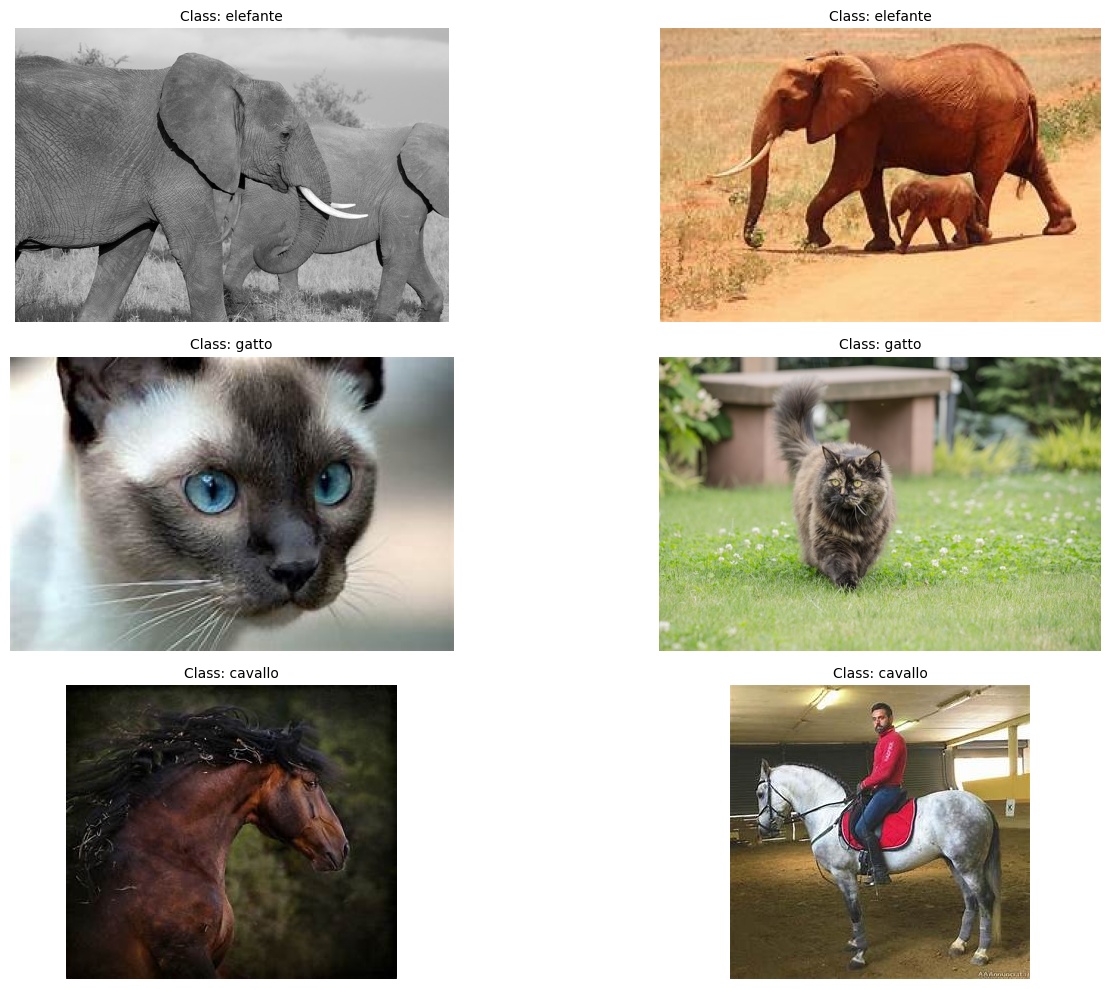

In [9]:
import os
import matplotlib.pyplot as plt
import random
import matplotlib.pyplot as plt
from PIL import Image

print("\nFolder contents：", os.listdir(dataset_path))

data_dir = os.path.join(dataset_path, "raw-img")

# Show all classes
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print("\nDataset Classes:", classes)

# 2 samples each for 3 random classes
num_classes = 3
num_samples_per_class = 2

# Figure creation
plt.figure(figsize=(15, 10))
plot_idx = 1

for cls in random.sample(classes, num_classes):
    cls_dir = os.path.join(data_dir, cls)
    img_files = [f for f in os.listdir(cls_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    # 2 samples
    sample_imgs = random.sample(img_files, num_samples_per_class)

    for img_name in sample_imgs:
        img_path = os.path.join(cls_dir, img_name)
        img = Image.open(img_path)
        plt.subplot(num_classes, num_samples_per_class, plot_idx)
        plt.imshow(img)
        plt.title(f"Class: {cls}", fontsize=10)
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

*  We can see in 'raw-img', the Dataset has 10 categories: **dog, cat, horse, spider, butterfly, chicken, sheep, cow, squirrel, elephant.**(actually it was initially posted with italian names)

**Part B: Validation strategy**


*   **Validation Strategy:**
1.   After each training epoch, model switches to eval mode.
2.   Uses torch.no_grad() to disable gradient computation for efficiency.
3.   Computes validation loss and accuracy on a held-out 20% subset of data (no weight updates).
4.   Tracks validation metrics to monitor overfitting and model generalization.


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Define transforms
# The model expects 128x128 input based on the flatten_dim calculation
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalize to [-1, 1]
])

# Load dataset
try:
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

    # Split into train and validation (80% train, 20% validation)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

    # Create DataLoaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"Total images: {len(full_dataset)}")
    print(f"Training set size: {len(train_dataset)}")
    print(f"Validation set size: {len(val_dataset)}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please ensure the correct former step about loading the dataset.")

Total images: 26179
Training set size: 20943
Validation set size: 5236


**Part C: Baseline model and Training Setup**
*   **Baseline:**
1.  Convolutional Layers:

    conv1: 3 input channels → 16 output channels (3x3 kernel, padding=1) + ReLU + 2x2 max pooling (stride=2).


    conv2: 16 input channels → 32 output channels (3x3 kernel, padding=1) + ReLU + 2x2 max pooling (stride=2).


    Spatial reduction: 128x128 input → 64x64 (after conv1) → 32x32 (after conv2).

2.  Dense Layers:

    Flattened features (32 channels × 32×32 spatial dims = 32768) fed to fc1 (128 units, ReLU).

    fc2 outputs 10 logits (for 10 classes).
3.  Runs on GPU (CUDA/MPS) if available, else CPU.

*   **Training Setup:**
1.  Loss function: CrossEntropyLoss (for multi-class classification).

2.  Optimizer: Adam with learning rate 0.001.

3.  Training loop: Iterates over epochs, with model in train mode. Computes loss on training batches, performs backpropagation, and updates weights. Tracks training loss and accuracy per epoch.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()
        # 2 convolution layers
        # Using Conv2D, ReLU and MaxPool
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 1 dense layer with:
        # Input layer – flattened features from the convolution layers
        # Hidden layer – 128 units
        # Output layer – the number of classes in the dataset

        # Note: The input dimension to the linear layer depends on the input image size.
        # Assuming input images are resized to 128x128.
        # After 2 pooling layers (dividing spatial dimensions by 2 each time):
        # 128 -> 64 -> 32
        # The feature map size will be 32x32 with 32 channels (from conv2).
        self.flatten_dim = 32 * 32 * 32

        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Convolution 1
        x = self.pool(F.relu(self.conv1(x)))
        # Convolution 2
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten
        x = x.view(-1, self.flatten_dim)

        # Dense layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Set random seed for reproducibility
torch.manual_seed(42)

# Check for device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize the model
model = BaselineCNN(num_classes=10).to(device)
print(model)

Using device: mps
BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
import torch.optim as optim
import time

# 2. Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    print("Starting training...")
    for epoch in range(num_epochs):
        start_time = time.time() # Start timer for the epoch

        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

        end_time = time.time() # End timer for the epoch
        epoch_duration = end_time - start_time

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
              f'Time: {epoch_duration:.2f}s')

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

# Train the model
# Adjust num_epochs as needed
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

Starting training...
Epoch 1/10: Train Loss: 1.6161 Acc: 0.4411 | Val Loss: 1.4468 Acc: 0.5074 | Time: 36.62s
Epoch 2/10: Train Loss: 1.0960 Acc: 0.6295 | Val Loss: 1.2082 Acc: 0.5930 | Time: 35.60s
Epoch 3/10: Train Loss: 0.7401 Acc: 0.7514 | Val Loss: 1.2537 Acc: 0.5943 | Time: 35.85s
Epoch 4/10: Train Loss: 0.4173 Acc: 0.8633 | Val Loss: 1.5464 Acc: 0.5907 | Time: 35.70s
Epoch 5/10: Train Loss: 0.1868 Acc: 0.9414 | Val Loss: 1.7795 Acc: 0.5911 | Time: 35.62s
Epoch 6/10: Train Loss: 0.0939 Acc: 0.9724 | Val Loss: 2.1640 Acc: 0.5867 | Time: 35.65s
Epoch 7/10: Train Loss: 0.0695 Acc: 0.9777 | Val Loss: 2.4472 Acc: 0.5867 | Time: 35.35s
Epoch 8/10: Train Loss: 0.0719 Acc: 0.9784 | Val Loss: 2.5449 Acc: 0.5749 | Time: 35.16s
Epoch 9/10: Train Loss: 0.0575 Acc: 0.9813 | Val Loss: 2.8653 Acc: 0.5966 | Time: 35.23s
Epoch 10/10: Train Loss: 0.0385 Acc: 0.9878 | Val Loss: 3.1650 Acc: 0.5886 | Time: 34.97s


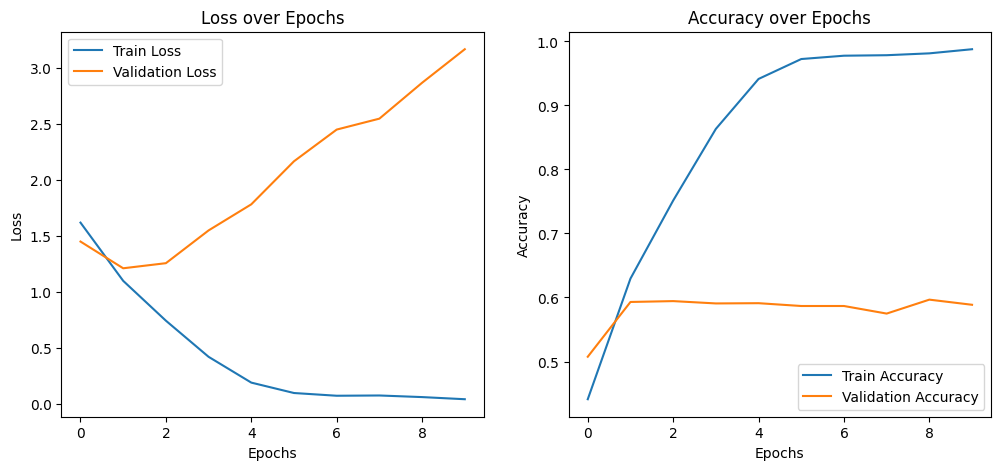

In [ ]:
# 3. Plotting Results
train_loss, train_acc, val_loss, val_acc = history

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

*   **Performance Analysis of BaselineCNN:**

1.   Loss Trends:
    
      Training loss decreases consistently from 1.616 to 0.038 over 10 epochs, indicating the model effectively learns patterns from the training data.

      Validation loss, however, rises steadily after epoch 2 (from 1.208 to 3.165), signaling the model fails to generalize to unseen data and instead memorizes training noise.
2.   Accuracy Trends:

      Training accuracy improves dramatically, reaching 98.78% by epoch 10, showing near-perfect classification on the training set.

      Validation accuracy plateaus around 58–59% after epoch 2, with no meaningful improvement (peaking at 59.66% in epoch 9). This gap (>39% by epoch 10) confirms severe overfitting.
3.   Summary:

      The training results reveal significant overfitting, with a stark divergence between training and validation metrics

      The simple 2-layer CNN lacks capacity to capture robust, generalizable features, leading to over-reliance on training-specific patterns.


**Part D: Improvement techniques**



*   **Improvement 1: Dropout:**

      A nn.Dropout(0.2) layer is added after the first fully connected layer (fc1), randomly zeroing 20% of activations during training.

In [ ]:
# --- Improvement 1: Dropout ---
class CNN_Dropout(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_Dropout, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten_dim = 32 * 32 * 32
        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.dropout = nn.Dropout(0.2) # Dropout layer with 20% probability
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.dropout(x) # Apply dropout before the final layer
        x = self.fc2(x)
        return x

print("Training CNN with Dropout...")
model_dropout = CNN_Dropout(num_classes=10).to(device)
optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=0.001)
history_dropout = train_model(model_dropout, train_loader, val_loader, criterion, optimizer_dropout, num_epochs=10)

Training CNN with Dropout...
Starting training...
Epoch 1/10: Train Loss: 1.8475 Acc: 0.3489 | Val Loss: 1.5160 Acc: 0.4853 | Time: 35.02s
Epoch 2/10: Train Loss: 1.4589 Acc: 0.4957 | Val Loss: 1.3661 Acc: 0.5311 | Time: 32.21s
Epoch 3/10: Train Loss: 1.2215 Acc: 0.5795 | Val Loss: 1.2106 Acc: 0.5966 | Time: 31.12s
Epoch 4/10: Train Loss: 1.0073 Acc: 0.6537 | Val Loss: 1.1899 Acc: 0.6127 | Time: 31.09s
Epoch 5/10: Train Loss: 0.8028 Acc: 0.7213 | Val Loss: 1.2224 Acc: 0.6154 | Time: 30.92s
Epoch 6/10: Train Loss: 0.6229 Acc: 0.7814 | Val Loss: 1.2451 Acc: 0.6222 | Time: 31.16s
Epoch 7/10: Train Loss: 0.4723 Acc: 0.8366 | Val Loss: 1.4362 Acc: 0.6098 | Time: 31.26s
Epoch 8/10: Train Loss: 0.3723 Acc: 0.8677 | Val Loss: 1.5792 Acc: 0.6098 | Time: 31.36s
Epoch 9/10: Train Loss: 0.3083 Acc: 0.8912 | Val Loss: 1.7054 Acc: 0.6003 | Time: 31.20s
Epoch 10/10: Train Loss: 0.2637 Acc: 0.9066 | Val Loss: 1.7375 Acc: 0.6104 | Time: 31.23s


*   **Improvement 2: Batch Normalization:**

      Two nn.BatchNorm2d layers are added: one after the first convolutional layer (conv1, applied to 16 channels) and another after the second convolutional layer (conv2, applied to 32 channels).

      The forward pass adjusts to follow the sequence: Conv2d → BatchNorm → ReLU → MaxPool, normalizing layer inputs to have zero mean and unit variance across each batch.

In [ ]:
# --- Improvement 2: Batch Normalization ---
class CNN_BatchNorm(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_BatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) # Batch Norm after Conv1
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32) # Batch Norm after Conv2
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten_dim = 32 * 32 * 32
        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # Conv -> BN -> ReLU -> Pool
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("\nTraining CNN with Batch Normalization...")
model_bn = CNN_BatchNorm(num_classes=10).to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)
history_bn = train_model(model_bn, train_loader, val_loader, criterion, optimizer_bn, num_epochs=10)


Training CNN with Batch Normalization...
Starting training...
Epoch 1/10: Train Loss: 2.1081 Acc: 0.2884 | Val Loss: 1.7307 Acc: 0.3963 | Time: 33.85s
Epoch 2/10: Train Loss: 1.6254 Acc: 0.4265 | Val Loss: 1.5281 Acc: 0.4633 | Time: 33.26s
Epoch 3/10: Train Loss: 1.4570 Acc: 0.4860 | Val Loss: 1.4987 Acc: 0.4675 | Time: 33.84s
Epoch 4/10: Train Loss: 1.3388 Acc: 0.5236 | Val Loss: 1.4329 Acc: 0.4964 | Time: 33.28s
Epoch 5/10: Train Loss: 1.2210 Acc: 0.5608 | Val Loss: 1.3545 Acc: 0.5309 | Time: 33.92s
Epoch 6/10: Train Loss: 1.1326 Acc: 0.5906 | Val Loss: 1.4697 Acc: 0.5139 | Time: 33.63s
Epoch 7/10: Train Loss: 1.0504 Acc: 0.6183 | Val Loss: 1.4460 Acc: 0.5212 | Time: 33.67s
Epoch 8/10: Train Loss: 0.9599 Acc: 0.6479 | Val Loss: 1.5326 Acc: 0.5222 | Time: 33.58s
Epoch 9/10: Train Loss: 0.8907 Acc: 0.6730 | Val Loss: 1.7133 Acc: 0.4694 | Time: 33.52s
Epoch 10/10: Train Loss: 0.8003 Acc: 0.7041 | Val Loss: 1.8033 Acc: 0.4830 | Time: 33.63s


*   **Improvement 3: Combination:**

In [ ]:
# --- Combined Improvements: Dropout + Batch Normalization ---
class CNN_Combined(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_Combined, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten_dim = 32 * 32 * 32
        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("\nTraining CNN with Dropout + Batch Normalization...")
model_combined = CNN_Combined(num_classes=10).to(device)
optimizer_combined = optim.Adam(model_combined.parameters(), lr=0.001)
history_combined = train_model(model_combined, train_loader, val_loader, criterion, optimizer_combined, num_epochs=10)


Training CNN with Dropout + Batch Normalization...
Starting training...
Epoch 1/10: Train Loss: 2.2340 Acc: 0.2471 | Val Loss: 1.9383 Acc: 0.3359 | Time: 33.92s
Epoch 2/10: Train Loss: 1.8655 Acc: 0.3435 | Val Loss: 1.7451 Acc: 0.3829 | Time: 33.41s
Epoch 3/10: Train Loss: 1.7031 Acc: 0.3894 | Val Loss: 1.5408 Acc: 0.4698 | Time: 33.95s
Epoch 4/10: Train Loss: 1.5981 Acc: 0.4235 | Val Loss: 1.5297 Acc: 0.4672 | Time: 33.68s
Epoch 5/10: Train Loss: 1.5145 Acc: 0.4541 | Val Loss: 1.4834 Acc: 0.4715 | Time: 34.15s
Epoch 6/10: Train Loss: 1.4269 Acc: 0.4858 | Val Loss: 1.3662 Acc: 0.5210 | Time: 34.52s
Epoch 7/10: Train Loss: 1.3532 Acc: 0.5100 | Val Loss: 1.2971 Acc: 0.5393 | Time: 35.60s
Epoch 8/10: Train Loss: 1.2833 Acc: 0.5317 | Val Loss: 1.3738 Acc: 0.5279 | Time: 35.38s
Epoch 9/10: Train Loss: 1.2071 Acc: 0.5535 | Val Loss: 1.3460 Acc: 0.5466 | Time: 35.63s
Epoch 10/10: Train Loss: 1.1486 Acc: 0.5722 | Val Loss: 1.2813 Acc: 0.5481 | Time: 38.01s


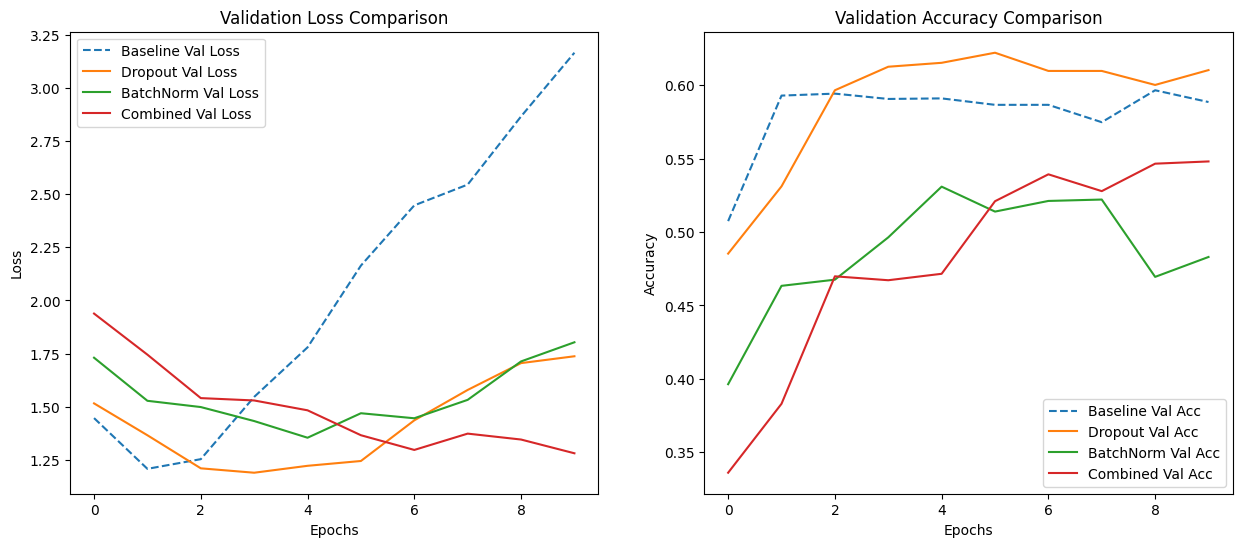

In [ ]:
# Compare Performance
plt.figure(figsize=(15, 6))

# Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history[2], label='Baseline Val Loss', linestyle='--')
plt.plot(history_dropout[2], label='Dropout Val Loss')
plt.plot(history_bn[2], label='BatchNorm Val Loss')
plt.plot(history_combined[2], label='Combined Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history[3], label='Baseline Val Acc', linestyle='--')
plt.plot(history_dropout[3], label='Dropout Val Acc')
plt.plot(history_bn[3], label='BatchNorm Val Acc')
plt.plot(history_combined[3], label='Combined Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

*  **Performance comparisons:**

1.  Dropout (20% Probability):
    
    Validation Loss: Remains the lowest among all models (~1.25–1.75) and stabilizes after epoch 2, avoiding the steep rise seen in the baseline.

    Validation Accuracy: Outperforms all others, reaching ~61–62% and maintaining consistency across epochs.

    Key Point: Effectively mitigates overfitting by randomly deactivating neurons, forcing the model to learn robust features.

2.  Batch Normalization:

    Validation Loss: Initially lower than the baseline but rises gradually to ~1.75, performing worse than Dropout.

    Validation Accuracy: Improves from ~40% to ~53% but plateaus below Dropout, showing limited generalization gains.

    Key Point: Fails to address overfitting on its own, leading to suboptimal performance.

3.  Combined (Dropout + Batch Normalization):

    Validation Loss: Starts low (~1.9) but increases moderately to ~1.3, better than BatchNorm alone but worse than Dropout.

    Validation Accuracy: Reaches ~55% but fluctuates, underperforming Dropout despite combining techniques.

    Key Point: The combination does not outperform dropout alone, possibly due to redundant regularization effects?

4.  Conclusion:

    Dropout (20%) emerges as the most effective modification, significantly reducing overfitting and achieving the highest validation accuracy (~62%). Batch normalization improves initial convergence but fails to prevent overfitting on its own, while their combination yields suboptimal results compared to dropout alone. This highlights dropout as the most impactful strategy for enhancing generalization in this setup.

**Part E: Model tuning**


*   **Increased Convolution Depth (32, 64 channels)**
      Upscaled the number of output channels in convolutional layers from the baseline (16 → 32 → 64 instead of 3 → 16 → 32).

*   **Increased Hidden Layer Size (256 units)**
      Enlarged the fully connected layer from 128 to 256 units in the dense block.

*   **Adding a Third Convolutional Layer**
      Introduced a third convolutional layer (32 → 64 channels) with an additional max-pooling step, increasing depth.


In [ ]:
# --- Tuning 1: Increased Convolution Depth (32, 64) ---
class CNN_IncreasedDepth(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_IncreasedDepth, self).__init__()
        # Increased channels: 3 -> 32 -> 64
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Feature map size is still 32x32, but now with 64 channels
        self.flatten_dim = 64 * 32 * 32
        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("\nTraining CNN with Increased Depth (32, 64)...")
model_depth = CNN_IncreasedDepth(num_classes=10).to(device)
optimizer_depth = optim.Adam(model_depth.parameters(), lr=0.001)
history_depth = train_model(model_depth, train_loader, val_loader, criterion, optimizer_depth, num_epochs=10)



Training CNN with Increased Depth (32, 64)...
Starting training...
Epoch 1/10: Train Loss: 1.7694 Acc: 0.3835 | Val Loss: 1.4400 Acc: 0.5061 | Time: 42.08s
Epoch 2/10: Train Loss: 1.2740 Acc: 0.5667 | Val Loss: 1.2887 Acc: 0.5586 | Time: 41.49s
Epoch 3/10: Train Loss: 1.0024 Acc: 0.6566 | Val Loss: 1.2028 Acc: 0.5911 | Time: 41.38s
Epoch 4/10: Train Loss: 0.7532 Acc: 0.7464 | Val Loss: 1.2995 Acc: 0.5934 | Time: 41.59s
Epoch 5/10: Train Loss: 0.4969 Acc: 0.8338 | Val Loss: 1.4579 Acc: 0.6020 | Time: 44.16s
Epoch 6/10: Train Loss: 0.2854 Acc: 0.9071 | Val Loss: 1.7964 Acc: 0.5854 | Time: 43.91s
Epoch 7/10: Train Loss: 0.1485 Acc: 0.9520 | Val Loss: 2.1852 Acc: 0.5837 | Time: 42.91s
Epoch 8/10: Train Loss: 0.1059 Acc: 0.9672 | Val Loss: 2.4695 Acc: 0.5760 | Time: 42.89s
Epoch 9/10: Train Loss: 0.0812 Acc: 0.9739 | Val Loss: 2.7807 Acc: 0.5831 | Time: 42.69s
Epoch 10/10: Train Loss: 0.0724 Acc: 0.9769 | Val Loss: 2.9436 Acc: 0.5773 | Time: 43.38s


In [ ]:
# --- Tuning 2: Increased Hidden Layer Size (256 units) ---
class CNN_HiddenSize(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_HiddenSize, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten_dim = 32 * 32 * 32
        # Increased hidden units: 128 -> 256
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("\nTraining CNN with Increased Hidden Size (256)...")
model_hidden = CNN_HiddenSize(num_classes=10).to(device)
optimizer_hidden = optim.Adam(model_hidden.parameters(), lr=0.001)
history_hidden = train_model(model_hidden, train_loader, val_loader, criterion, optimizer_hidden, num_epochs=10)



Training CNN with Increased Hidden Size (256)...
Starting training...
Epoch 1/10: Train Loss: 1.5949 Acc: 0.4483 | Val Loss: 1.2959 Acc: 0.5558 | Time: 34.24s
Epoch 2/10: Train Loss: 1.0574 Acc: 0.6420 | Val Loss: 1.1721 Acc: 0.6029 | Time: 34.23s
Epoch 3/10: Train Loss: 0.6522 Acc: 0.7826 | Val Loss: 1.2178 Acc: 0.6133 | Time: 34.30s
Epoch 4/10: Train Loss: 0.2794 Acc: 0.9117 | Val Loss: 1.5374 Acc: 0.6050 | Time: 35.43s
Epoch 5/10: Train Loss: 0.0991 Acc: 0.9710 | Val Loss: 2.0338 Acc: 0.5919 | Time: 34.74s
Epoch 6/10: Train Loss: 0.0637 Acc: 0.9828 | Val Loss: 2.3166 Acc: 0.6050 | Time: 34.77s
Epoch 7/10: Train Loss: 0.0438 Acc: 0.9868 | Val Loss: 2.4487 Acc: 0.5854 | Time: 34.16s
Epoch 8/10: Train Loss: 0.0571 Acc: 0.9832 | Val Loss: 2.6984 Acc: 0.5852 | Time: 34.70s
Epoch 9/10: Train Loss: 0.0552 Acc: 0.9821 | Val Loss: 2.6584 Acc: 0.5951 | Time: 34.53s
Epoch 10/10: Train Loss: 0.0401 Acc: 0.9887 | Val Loss: 2.7593 Acc: 0.5974 | Time: 34.57s


In [ ]:
# --- Tuning 3: Adding a Third Convolutional Layer ---
class CNN_ThreeLayers(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_ThreeLayers, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        # Added 3rd Conv Layer: 32 -> 64
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # After 3 pooling layers: 128 -> 64 -> 32 -> 16
        # Feature map size: 16x16 with 64 channels
        self.flatten_dim = 64 * 16 * 16
        self.fc1 = nn.Linear(self.flatten_dim, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x))) # 3rd Conv Block
        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("\nTraining CNN with 3 Convolutional Layers...")
model_3layers = CNN_ThreeLayers(num_classes=10).to(device)
optimizer_3layers = optim.Adam(model_3layers.parameters(), lr=0.001)
history_3layers = train_model(model_3layers, train_loader, val_loader, criterion, optimizer_3layers, num_epochs=10)


Training CNN with 3 Convolutional Layers...
Starting training...
Epoch 1/10: Train Loss: 1.7006 Acc: 0.4125 | Val Loss: 1.3138 Acc: 0.5426 | Time: 33.42s
Epoch 2/10: Train Loss: 1.1702 Acc: 0.5998 | Val Loss: 1.1204 Acc: 0.6239 | Time: 32.35s
Epoch 3/10: Train Loss: 0.9265 Acc: 0.6858 | Val Loss: 1.0729 Acc: 0.6499 | Time: 32.76s
Epoch 4/10: Train Loss: 0.7123 Acc: 0.7590 | Val Loss: 1.0830 Acc: 0.6696 | Time: 32.30s
Epoch 5/10: Train Loss: 0.4943 Acc: 0.8344 | Val Loss: 1.1679 Acc: 0.6507 | Time: 33.56s
Epoch 6/10: Train Loss: 0.3189 Acc: 0.8926 | Val Loss: 1.4077 Acc: 0.6490 | Time: 32.19s
Epoch 7/10: Train Loss: 0.1830 Acc: 0.9392 | Val Loss: 1.7872 Acc: 0.6469 | Time: 33.83s
Epoch 8/10: Train Loss: 0.1190 Acc: 0.9612 | Val Loss: 2.0835 Acc: 0.6408 | Time: 33.26s
Epoch 9/10: Train Loss: 0.0861 Acc: 0.9703 | Val Loss: 2.3957 Acc: 0.6411 | Time: 35.26s
Epoch 10/10: Train Loss: 0.0903 Acc: 0.9707 | Val Loss: 2.3408 Acc: 0.6438 | Time: 35.05s


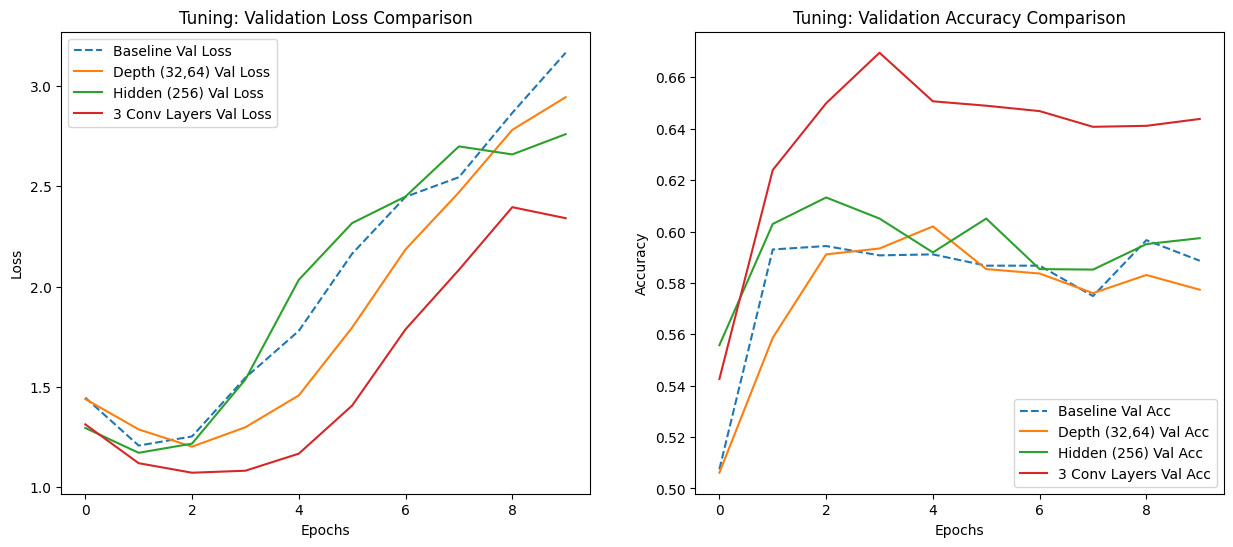

In [ ]:
# Compare Tuning Results
plt.figure(figsize=(15, 6))

# Validation Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history[2], label='Baseline Val Loss', linestyle='--')
plt.plot(history_depth[2], label='Depth (32,64) Val Loss')
plt.plot(history_hidden[2], label='Hidden (256) Val Loss')
plt.plot(history_3layers[2], label='3 Conv Layers Val Loss')
plt.title('Tuning: Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Validation Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history[3], label='Baseline Val Acc', linestyle='--')
plt.plot(history_depth[3], label='Depth (32,64) Val Acc')
plt.plot(history_hidden[3], label='Hidden (256) Val Acc')
plt.plot(history_3layers[3], label='3 Conv Layers Val Acc')
plt.title('Tuning: Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

*  **Performance comparisons:**

1.  Increased Convolution Depth (32, 64 channels)
    
    Validation Loss: Rises steeply after epoch 4, exceeding the baseline by epoch 10 (~2.9 vs. baseline’s ~3.2), indicating moderate overfitting.

    Validation Accuracy: Peaks around 0.60 (epoch 4) but declines to ~0.58 by epoch 10, performing slightly better than the baseline but worse than other tunings.

    Conclusion: Expanding channel depth improves initial performance but fails to sustain generalization.

2.  Increased Hidden Layer Size (256 units)

    Validation Loss: Shows the steepest rise among tunings, reaching ~2.8 by epoch 10, indicating significant overfitting.

    Validation Accuracy: Peaks early at ~0.61 (epoch 2) but drops to ~0.59, underperforming the 3-layer model and failing to outpace the baseline in the long run.

    Conclusion: Larger dense layers enhance early learning but exacerbate overfitting.

3.  Adding a Third Convolutional Layer

    Validation Loss: Remains the lowest across all models (~2.3 at epoch 10) and stabilizes after epoch 6, showing the best resistance to overfitting.
    
    Validation Accuracy: Achieves the highest peak and maintains the highest performance by epoch 10, outperforming all other models.

    Conclusion: Increasing depth with a third convolutional layer (plus extra pooling) enables more robust hierarchical feature learning, balancing capacity and generalization effectively.

**Part F: Final Summary**

The **3 Convolutional Layers model** remains the best-performing model across all modifications (improvements+tunings),because it addresses the core limitation of the baseline (shallow feature learning) through structured depth, rather than just mitigating overfitting (Dropout/BatchNorm) or blindly scaling parameters (channel/hidden size). This structural improvement enables it to learn more robust, generalizable features.